# Hurricane Resource Allocation — Presentation Charts

Run **Setup** first, then any individual cell.

- **Chart 1** — Full System Architecture (8-layer pipeline)
- **Chart 2** — The Zero-Inflation Problem (Panels A–H)
- **Chart 3** — Solution Approaches


## Setup
Run this cell first — loads data and defines all shared helpers.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd
from pathlib import Path

PROC = Path("../data/processed")
panel = pd.read_parquet(PROC / "panel.parquet")
preds = pd.read_parquet(PROC / "predictions.parquet")
demand   = panel["demand_proxy"]
pred_all = preds["pred_demand"]
act_all  = preds["demand_proxy"]

RED="#c0392b"; ORANGE="#e67e22"; GREEN="#27ae60"; BLUE="#2980b9"
PURPLE="#8e44ad"; GREY="#95a5a6"; DARK="#1a1a1a"; BG="#fdfefe"
C = {
    "source":"#1a5276","script":"#1e8449","data":"#d4e6f1","model":"#7d3c98",
    "optim":"#b7770d","output":"#922b21","text_lt":"#ffffff","text_dk":"#1a1a1a",
    "approach1":"#1a5276","approach2":"#1e8449","approach3":"#7d3c98",
    "pro":"#1e8449","con":"#c0392b","dark":"#1a1a1a",
    "light_1":"#d4e6f1","light_2":"#d5f5e3","light_3":"#e8daef","header":"#2c3e50",
}

def box(ax, x, y, w, h, label, sublabel="", color="#1a5276",
        text_color="white", fontsize=9, radius=0.25):
    ax.add_patch(FancyBboxPatch((x,y), w, h,
        boxstyle=f"round,pad=0,rounding_size={radius}",
        linewidth=1.2, edgecolor="white", facecolor=color, zorder=3))
    if sublabel:
        ax.text(x+w/2,y+h*0.62,label,ha="center",va="center",color=text_color,fontsize=fontsize,fontweight="bold",zorder=4)
        ax.text(x+w/2,y+h*0.28,sublabel,ha="center",va="center",color=text_color,fontsize=fontsize-1.5,style="italic",zorder=4)
    else:
        ax.text(x+w/2,y+h/2,label,ha="center",va="center",color=text_color,fontsize=fontsize,fontweight="bold",zorder=4)

def arrow(ax, x1, y1, x2, y2, color="#555555", lw=1.8):
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
        arrowprops=dict(arrowstyle="-|>",color=color,lw=lw,mutation_scale=14), zorder=2)

def fbox(ax, x, y, w, h, title, body, fc, tc="white", fs=8.5):
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle="round,pad=0,rounding_size=0.2",
        facecolor=fc,edgecolor="white",lw=1.2,zorder=3))
    ax.text(x+w/2,y+h*0.68,title,ha="center",va="center",color=tc,fontsize=fs,fontweight="bold",zorder=4)
    ax.text(x+w/2,y+h*0.28,body,ha="center",va="center",color=tc,fontsize=fs-1.2,zorder=4,linespacing=1.3)

def farr(ax, x1, y1, x2, y2, c="#555555"):
    ax.annotate("",xy=(x2,y2),xytext=(x1,y1),
        arrowprops=dict(arrowstyle="-|>",color=c,lw=2,mutation_scale=14),zorder=5)

def divider(ax, y, color="#dddddd"):
    ax.axhline(y,color=color,lw=0.8,linestyle="--",zorder=1)

def slabel(ax, x, y, text):
    ax.text(x,y,text,ha="left",va="center",fontsize=8.5,color="#777777",style="italic",zorder=5)

print(f"panel {panel.shape} | preds {preds.shape} | zeros {(demand==0).mean()*100:.1f}%")


panel (31045, 50) | preds (8542, 28) | zeros 79.1%


---
## Chart 1 — Full System Architecture
8-layer end-to-end pipeline: 5 data sources → 10 scripts → 3 policies → 6 output figures.

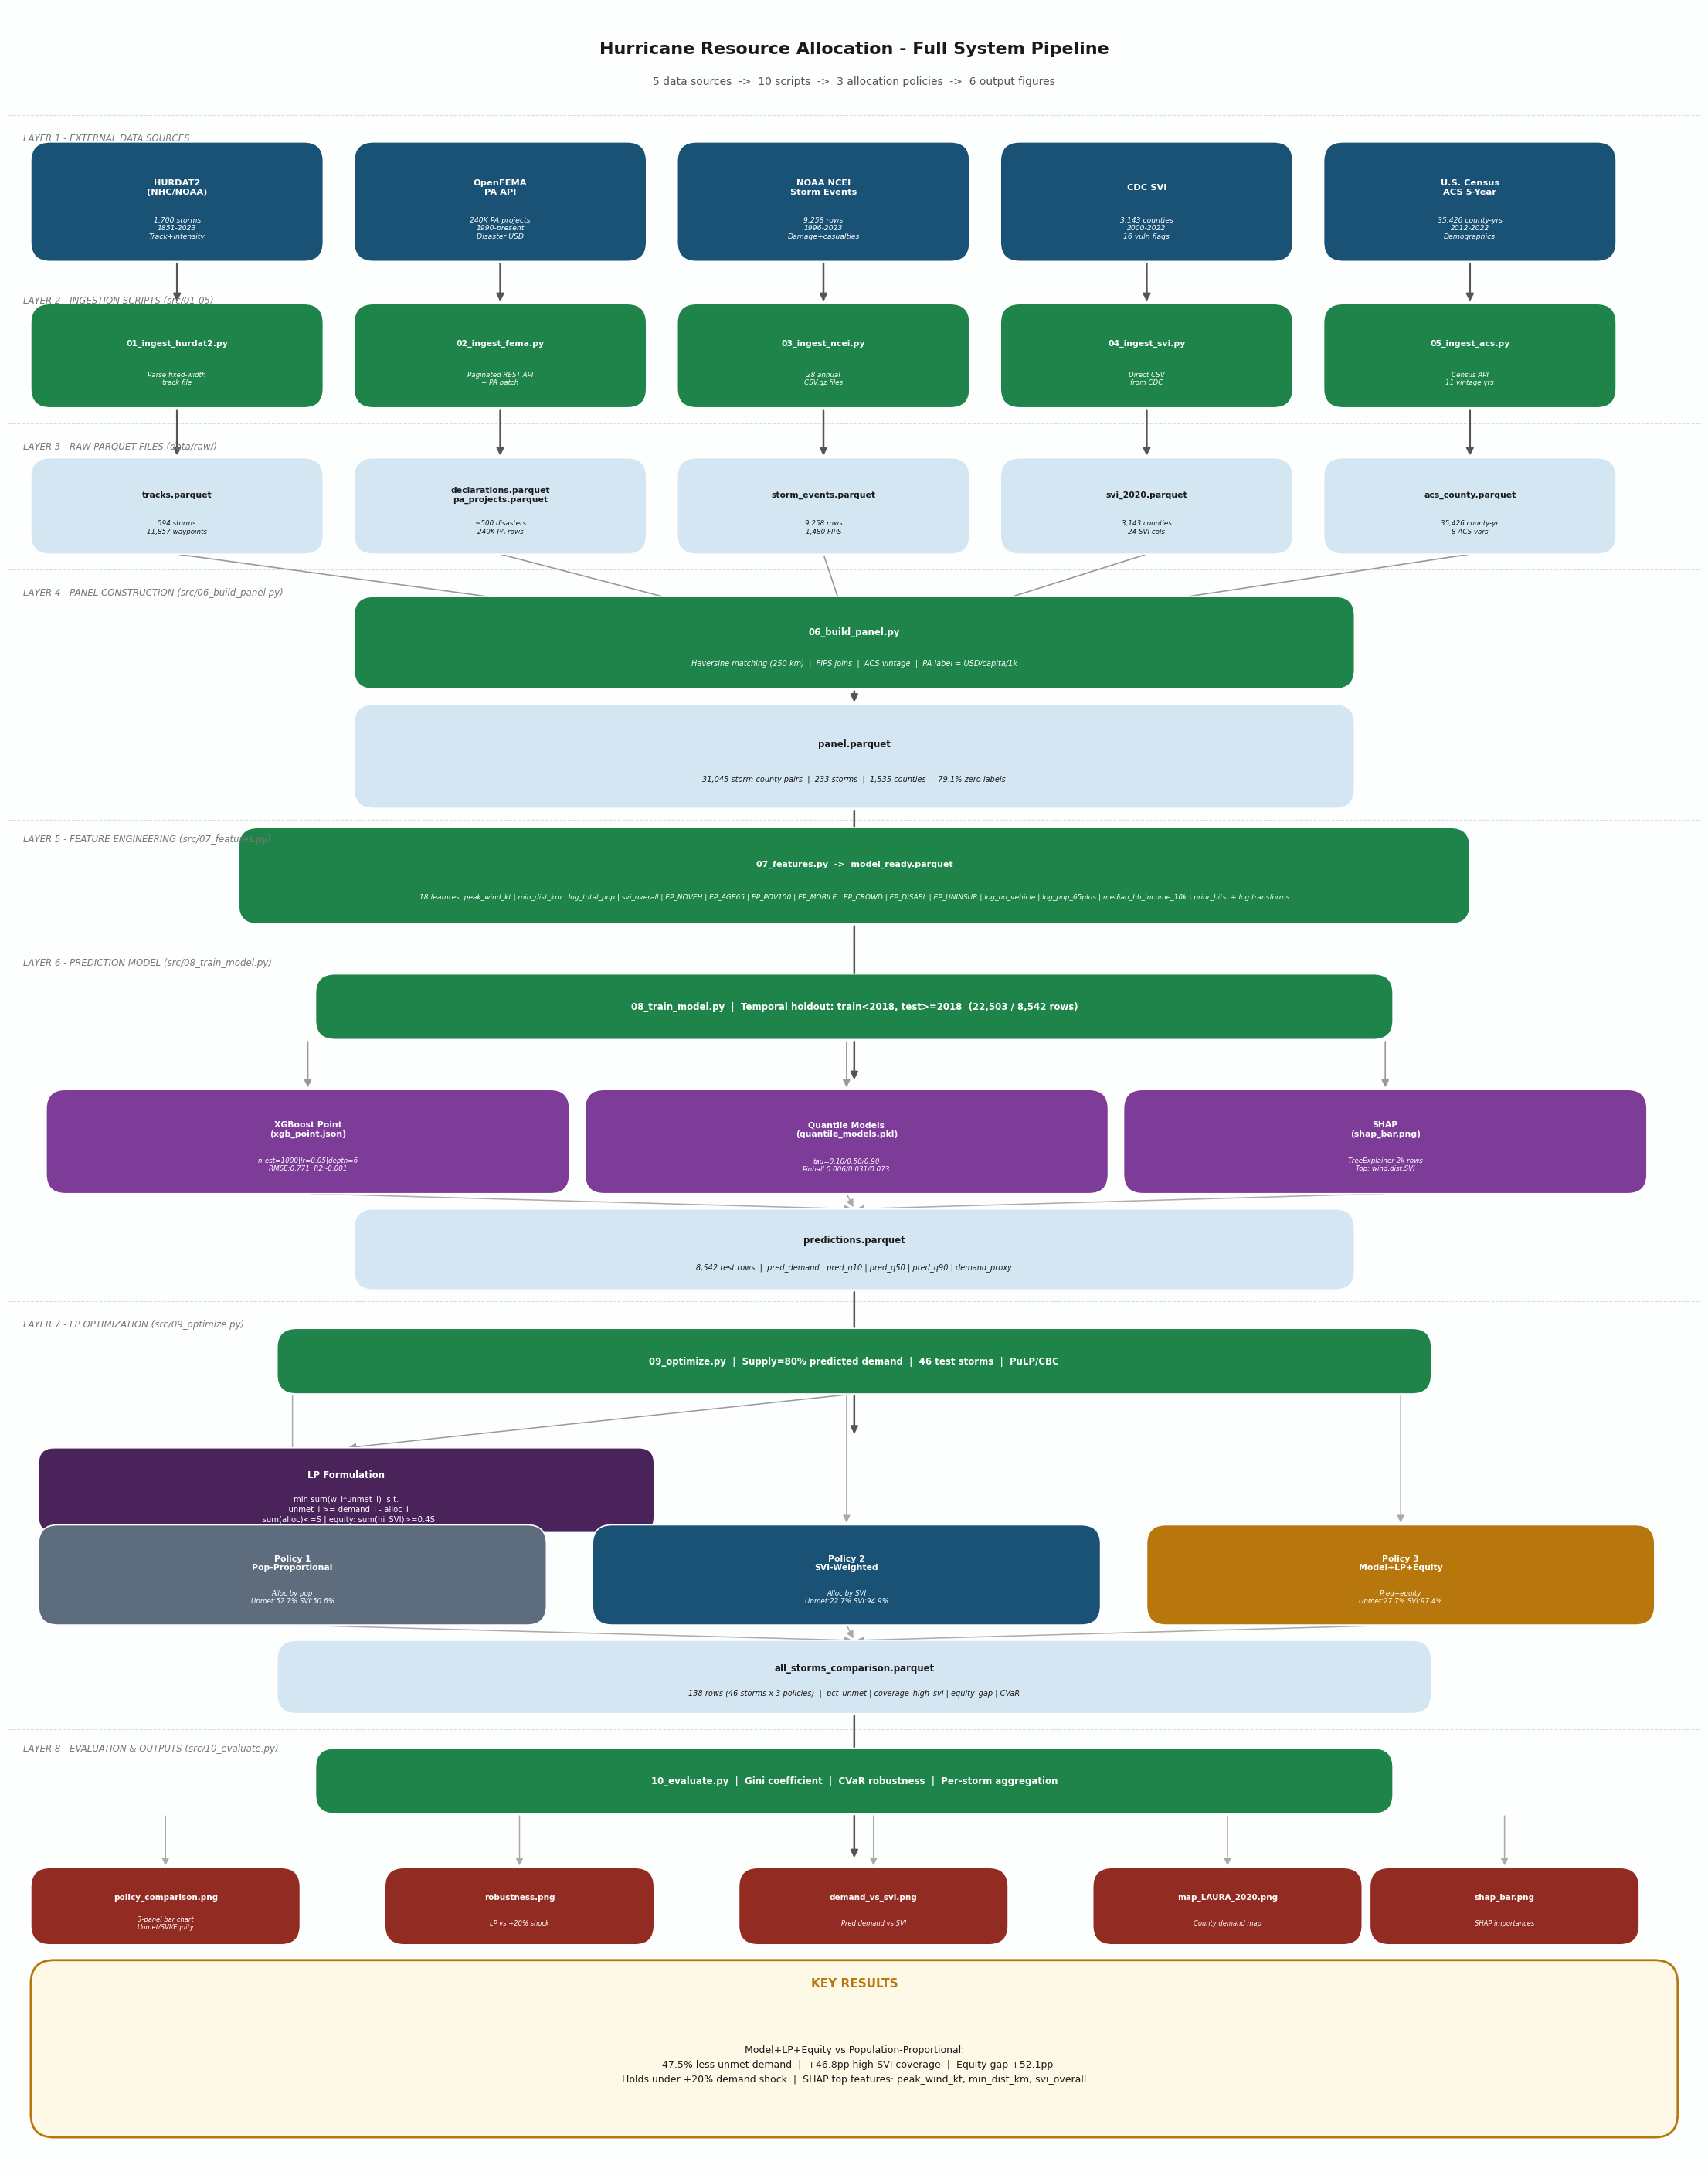

In [2]:
fig, ax = plt.subplots(figsize=(22, 28))
ax.set_xlim(0,22); ax.set_ylim(0,28); ax.axis("off")
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

ax.text(11,27.4,"Hurricane Resource Allocation - Full System Pipeline",
        ha="center",fontsize=16,fontweight="bold",color=DARK)
ax.text(11,27.0,"5 data sources  ->  10 scripts  ->  3 allocation policies  ->  6 output figures",
        ha="center",fontsize=10,color="#555555")

src_xs = [0.3,4.5,8.7,12.9,17.1]

# Layer 1
divider(ax,26.6); slabel(ax,0.2,26.3,"LAYER 1 - EXTERNAL DATA SOURCES")
for (lbl,sub),sx in zip([
    ("HURDAT2\n(NHC/NOAA)",    "1,700 storms\n1851-2023\nTrack+intensity"),
    ("OpenFEMA\nPA API",       "240K PA projects\n1990-present\nDisaster USD"),
    ("NOAA NCEI\nStorm Events","9,258 rows\n1996-2023\nDamage+casualties"),
    ("CDC SVI",                 "3,143 counties\n2000-2022\n16 vuln flags"),
    ("U.S. Census\nACS 5-Year","35,426 county-yrs\n2012-2022\nDemographics"),
], src_xs):
    box(ax,sx,24.7,3.8,1.55,lbl,sub,color=C["source"],fontsize=8.2)

# Layer 2
divider(ax,24.5); slabel(ax,0.2,24.2,"LAYER 2 - INGESTION SCRIPTS (src/01-05)")
for (lbl,sub),sx in zip([
    ("01_ingest_hurdat2.py","Parse fixed-width\ntrack file"),
    ("02_ingest_fema.py",  "Paginated REST API\n+ PA batch"),
    ("03_ingest_ncei.py",  "28 annual\nCSV.gz files"),
    ("04_ingest_svi.py",   "Direct CSV\nfrom CDC"),
    ("05_ingest_acs.py",   "Census API\n11 vintage yrs"),
], src_xs):
    box(ax,sx,22.8,3.8,1.35,lbl,sub,color=C["script"],fontsize=7.8)
    arrow(ax,sx+1.9,24.7,sx+1.9,22.8+1.35)

# Layer 3
divider(ax,22.6); slabel(ax,0.2,22.3,"LAYER 3 - RAW PARQUET FILES (data/raw/)")
for (lbl,sub),sx in zip([
    ("tracks.parquet",                         "594 storms\n11,857 waypoints"),
    ("declarations.parquet\npa_projects.parquet","~500 disasters\n240K PA rows"),
    ("storm_events.parquet",                   "9,258 rows\n1,480 FIPS"),
    ("svi_2020.parquet",                       "3,143 counties\n24 SVI cols"),
    ("acs_county.parquet",                     "35,426 county-yr\n8 ACS vars"),
], src_xs):
    box(ax,sx,20.9,3.8,1.25,lbl,sub,color=C["data"],text_color=C["text_dk"],fontsize=7.8)
    arrow(ax,sx+1.9,22.8,sx+1.9,20.9+1.25)

# Layer 4
divider(ax,20.7); slabel(ax,0.2,20.4,"LAYER 4 - PANEL CONSTRUCTION (src/06_build_panel.py)")
for sx in src_xs:
    arrow(ax,sx+1.9,20.9,11.0,19.7,color="#999999",lw=1.2)
box(ax,4.5,19.15,13.0,1.2,"06_build_panel.py",
    "Haversine matching (250 km)  |  FIPS joins  |  ACS vintage  |  PA label = USD/capita/1k",
    color=C["script"],fontsize=8.5)
box(ax,4.5,17.6,13.0,1.35,"panel.parquet",
    "31,045 storm-county pairs  |  233 storms  |  1,535 counties  |  79.1% zero labels",
    color=C["data"],text_color=C["text_dk"],fontsize=8.5)
arrow(ax,11.0,19.15,11.0,18.95)

# Layer 5
divider(ax,17.45); slabel(ax,0.2,17.2,"LAYER 5 - FEATURE ENGINEERING (src/07_features.py)")
arrow(ax,11.0,17.6,11.0,16.65)
box(ax,3.0,16.1,16.0,1.25,"07_features.py  ->  model_ready.parquet",
    "18 features: peak_wind_kt | min_dist_km | log_total_pop | svi_overall | EP_NOVEH | EP_AGE65 | EP_POV150 | EP_MOBILE | EP_CROWD | EP_DISABL | EP_UNINSUR | log_no_vehicle | log_pop_65plus | median_hh_income_10k | prior_hits  + log transforms",
    color=C["script"],fontsize=8.0)

# Layer 6
divider(ax,15.9); slabel(ax,0.2,15.6,"LAYER 6 - PREDICTION MODEL (src/08_train_model.py)")
arrow(ax,11.0,16.1,11.0,15.2)
box(ax,4.0,14.6,14.0,0.85,
    "08_train_model.py  |  Temporal holdout: train<2018, test>=2018  (22,503 / 8,542 rows)",
    color=C["script"],fontsize=8.5)
arrow(ax,11.0,14.6,11.0,14.05)
for (lbl,sub),mx in zip([
    ("XGBoost Point\n(xgb_point.json)",       "n_est=1000|lr=0.05|depth=6\nRMSE:0.771  R2:-0.001"),
    ("Quantile Models\n(quantile_models.pkl)", "tau=0.10/0.50/0.90\nPinball:0.006/0.031/0.073"),
    ("SHAP\n(shap_bar.png)",                  "TreeExplainer 2k rows\nTop: wind,dist,SVI"),
], [0.5,7.5,14.5]):
    box(ax,mx,12.6,6.8,1.35,lbl,sub,color=C["model"],fontsize=7.8)
    arrow(ax,mx+3.4,14.6,mx+3.4,12.6+1.35,color="#999999",lw=1.2)
box(ax,4.5,11.35,13.0,1.05,"predictions.parquet",
    "8,542 test rows  |  pred_demand | pred_q10 | pred_q50 | pred_q90 | demand_proxy",
    color=C["data"],text_color=C["text_dk"],fontsize=8.5)
for mx in [0.5,7.5,14.5]:
    arrow(ax,mx+3.4,12.6,11.0,11.35+1.05,color="#aaaaaa",lw=1.1)

# Layer 7
divider(ax,11.2); slabel(ax,0.2,10.9,"LAYER 7 - LP OPTIMIZATION (src/09_optimize.py)")
arrow(ax,11.0,11.35,11.0,10.55)
box(ax,3.5,10.0,15.0,0.85,
    "09_optimize.py  |  Supply=80% predicted demand  |  46 test storms  |  PuLP/CBC",
    color=C["script"],fontsize=8.5)
arrow(ax,11.0,10.0,11.0,9.45)
fbox(ax,0.4,8.2,8.0,1.1,"LP Formulation",
     "min sum(w_i*unmet_i)  s.t.\n  unmet_i >= demand_i - alloc_i\n  sum(alloc)<=S | equity: sum(hi_SVI)>=0.4S",
     "#4a235a")
arrow(ax,11.0,10.0,4.4,8.2+1.1,color="#999999",lw=1.1)
for (lbl,sub),px,pc in zip([
    ("Policy 1\nPop-Proportional", "Alloc by pop\nUnmet:52.7% SVI:50.6%"),
    ("Policy 2\nSVI-Weighted",     "Alloc by SVI\nUnmet:22.7% SVI:94.9%"),
    ("Policy 3\nModel+LP+Equity",  "Pred+equity\nUnmet:27.7% SVI:97.4%"),
], [0.4,7.6,14.8], ["#5d6d7e","#1a5276",C["optim"]]):
    box(ax,px,7.0,6.6,1.3,lbl,sub,color=pc,fontsize=7.8)
    arrow(ax,px+3.3,10.0,px+3.3,7.0+1.3,color="#aaaaaa",lw=1.1)
box(ax,3.5,5.85,15.0,0.95,"all_storms_comparison.parquet",
    "138 rows (46 storms x 3 policies)  |  pct_unmet | coverage_high_svi | equity_gap | CVaR",
    color=C["data"],text_color=C["text_dk"],fontsize=8.5)
for px in [0.4,7.6,14.8]:
    arrow(ax,px+3.3,7.0,11.0,5.85+0.95,color="#aaaaaa",lw=1.1)

# Layer 8
divider(ax,5.65); slabel(ax,0.2,5.4,"LAYER 8 - EVALUATION & OUTPUTS (src/10_evaluate.py)")
arrow(ax,11.0,5.85,11.0,5.1)
box(ax,4.0,4.55,14.0,0.85,
    "10_evaluate.py  |  Gini coefficient  |  CVaR robustness  |  Per-storm aggregation",
    color=C["script"],fontsize=8.5)
arrow(ax,11.0,4.55,11.0,3.95)
for (lbl,sub),ox in zip([
    ("policy_comparison.png","3-panel bar chart\nUnmet/SVI/Equity"),
    ("robustness.png",       "LP vs +20% shock"),
    ("demand_vs_svi.png",    "Pred demand vs SVI"),
    ("map_LAURA_2020.png",   "County demand map"),
    ("shap_bar.png",         "SHAP importances"),
], [0.3,4.9,9.5,14.1,17.7]):
    box(ax,ox,2.85,3.5,1.0,lbl,sub,color=C["output"],fontsize=7.5)
    arrow(ax,ox+1.75,4.55,ox+1.75,2.85+1.0,color="#aaaaaa",lw=1.1)

# Key results banner
ax.add_patch(FancyBboxPatch((0.3,0.35),21.4,2.3,
    boxstyle="round,pad=0,rounding_size=0.3",
    linewidth=2,edgecolor=C["optim"],facecolor="#fef9e7",zorder=3))
ax.text(11,2.3,"KEY RESULTS",ha="center",fontsize=11,fontweight="bold",color=C["optim"])
ax.text(11,1.3,
    "Model+LP+Equity vs Population-Proportional:\n"
    "  47.5% less unmet demand  |  +46.8pp high-SVI coverage  |  Equity gap +52.1pp\n"
    "Holds under +20% demand shock  |  SHAP top features: peak_wind_kt, min_dist_km, svi_overall",
    ha="center",va="center",fontsize=9,color=DARK,linespacing=1.6)

plt.tight_layout(pad=0.3)
plt.show()


---
## Chart 2 — The Zero-Inflation Problem
79.1% of storm-county pairs have zero demand. XGBoost collapses to predicting near-mean, giving R² ≈ 0.

### Panel A — Non-Zero Demand Distribution
Histogram of demand_proxy for rows where demand > 0 (log-scale y-axis shows heavy right tail).

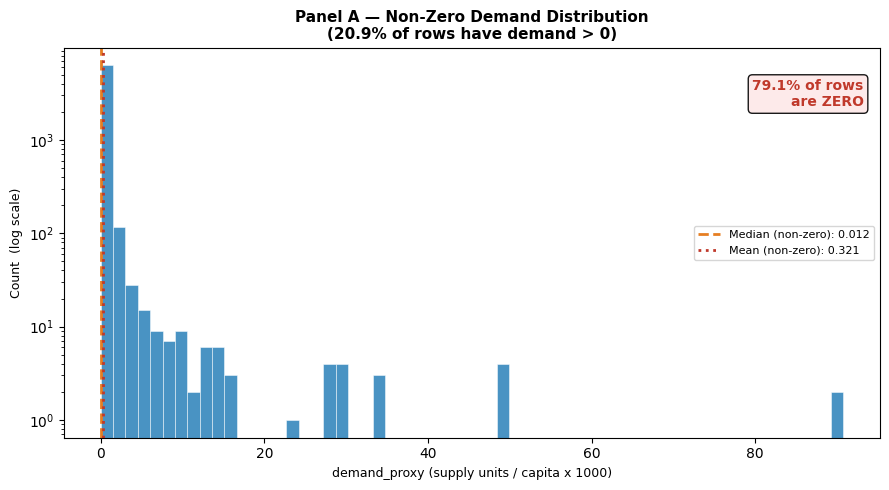

In [3]:
zero_frac = (demand == 0).mean()
nonzero   = demand[demand > 0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(nonzero, bins=60, color=BLUE, alpha=0.85, edgecolor="white", linewidth=0.4, log=True)
ax.axvline(nonzero.median(), color=ORANGE, lw=2, linestyle="--",
           label=f"Median (non-zero): {nonzero.median():.3f}")
ax.axvline(nonzero.mean(),   color=RED,    lw=2, linestyle=":",
           label=f"Mean (non-zero): {nonzero.mean():.3f}")
ax.set_xlabel("demand_proxy (supply units / capita x 1000)", fontsize=9)
ax.set_ylabel("Count  (log scale)", fontsize=9)
ax.set_title(f"Panel A — Non-Zero Demand Distribution\n({(1-zero_frac)*100:.1f}% of rows have demand > 0)",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=8)
ax.text(0.98, 0.92, f"{zero_frac*100:.1f}% of rows\nare ZERO",
        transform=ax.transAxes, ha="right", va="top", fontsize=10, color=RED, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#fde8e8", alpha=0.9))
plt.tight_layout(); plt.show()


### Panel B — Label Distribution (Pie)
31,045 storm-county pairs: 79.1% zeros vs 20.9% non-zero demand.

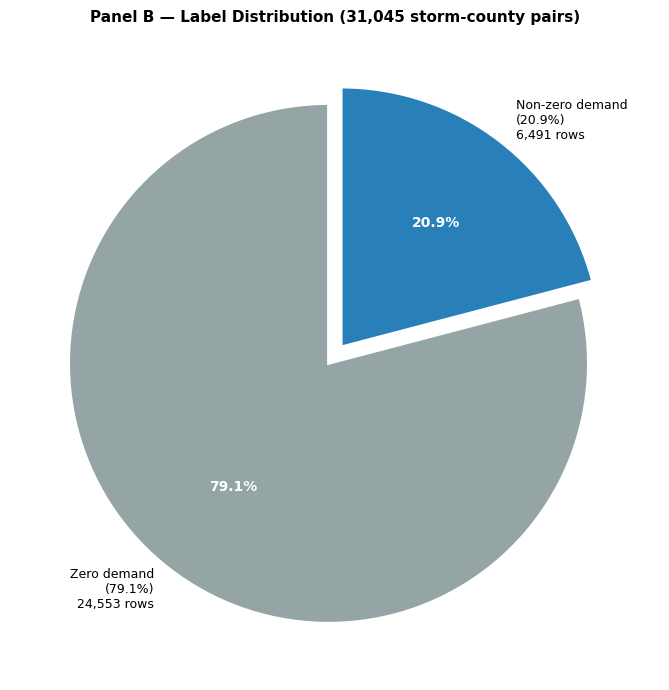

In [4]:
zero_frac = (demand == 0).mean()
fig, ax = plt.subplots(figsize=(7, 7))
sizes  = [zero_frac*100, (1-zero_frac)*100]
labels = [f"Zero demand\n({zero_frac*100:.1f}%)\n{int(zero_frac*len(demand)):,} rows",
          f"Non-zero demand\n({(1-zero_frac)*100:.1f}%)\n{int((1-zero_frac)*len(demand)):,} rows"]
wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=[GREY, BLUE], explode=(0.04,0.04),
    autopct="%1.1f%%", startangle=90,
    textprops={"fontsize":9}, wedgeprops={"edgecolor":"white","linewidth":2})
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight("bold"); at.set_color("white")
ax.set_title("Panel B — Label Distribution (31,045 storm-county pairs)",
             fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()


### Panel C — Demand by FEMA Declaration Status
FEMA-declared counties have ~41% non-zero demand; not-declared is near 0%. This is the key signal.

c:\Users\shubb\anaconda3\envs\hurricane\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


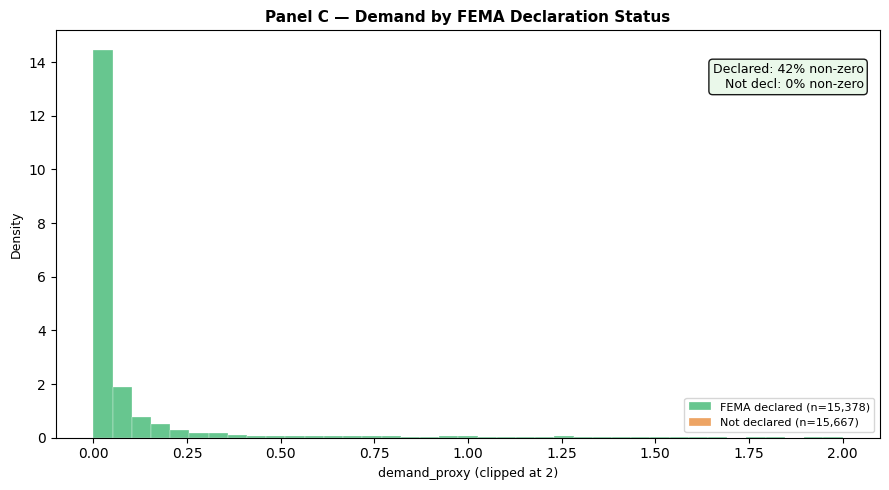

In [5]:
declared     = panel[panel["fema_declared"] == 1]["demand_proxy"]
not_declared = panel[panel["fema_declared"] == 0]["demand_proxy"]

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, 2, 40)
ax.hist(declared[declared>0],     bins=bins, alpha=0.7, color=GREEN,  density=True,
        edgecolor="white", lw=0.3, label=f"FEMA declared (n={len(declared):,})")
ax.hist(not_declared[not_declared>0], bins=bins, alpha=0.7, color=ORANGE, density=True,
        edgecolor="white", lw=0.3, label=f"Not declared (n={len(not_declared):,})")
ax.set_xlabel("demand_proxy (clipped at 2)", fontsize=9)
ax.set_ylabel("Density", fontsize=9)
ax.set_title("Panel C — Demand by FEMA Declaration Status", fontsize=11, fontweight="bold")
ax.legend(fontsize=8)
ax.text(0.98, 0.92,
        f"Declared: {(declared>0).mean()*100:.0f}% non-zero\nNot decl: {(not_declared>0).mean()*100:.0f}% non-zero",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#e8f8e8", alpha=0.9))
plt.tight_layout(); plt.show()


### Panel D — Predicted vs Actual Demand (Test Set)
R² = -0.001. All predictions cluster near the mean — the model cannot differentiate high-demand counties.

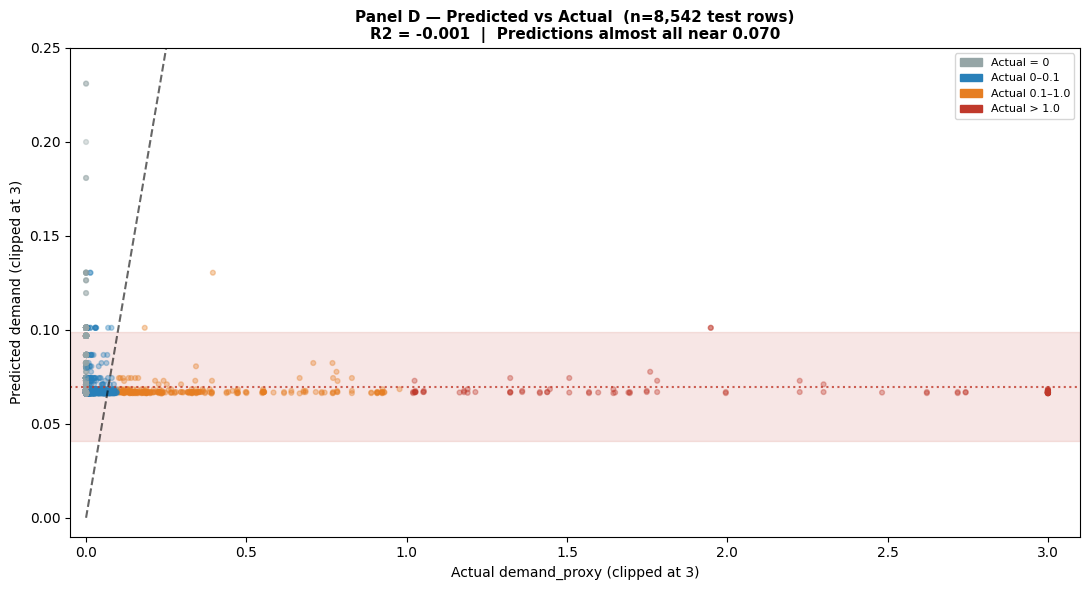

In [6]:
clip_val  = 3.0
act_c     = act_all.clip(upper=clip_val)
pre_c     = pred_all.clip(upper=clip_val)
color_map = np.where(act_all==0, GREY,
            np.where(act_all<=0.1, BLUE,
            np.where(act_all<=1.0, ORANGE, RED)))
pred_mean = pred_all.mean(); pred_std = pred_all.std()

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(act_c, pre_c, c=color_map, alpha=0.35, s=12, zorder=2)
ax.plot([0,clip_val],[0,clip_val], "k--", lw=1.5, alpha=0.6, label="Perfect prediction")
ax.axhspan(pred_mean-pred_std, pred_mean+pred_std, alpha=0.12, color=RED,
           label=f"Pred band: {pred_mean:.3f} +/- {pred_std:.3f}")
ax.axhline(pred_mean, color=RED, lw=1.5, linestyle=":", alpha=0.8)
ax.set_xlabel("Actual demand_proxy (clipped at 3)", fontsize=10)
ax.set_ylabel("Predicted demand (clipped at 3)", fontsize=10)
ax.set_title(f"Panel D — Predicted vs Actual  (n={len(act_all):,} test rows)\nR2 = -0.001  |  Predictions almost all near {pred_mean:.3f}",
             fontsize=11, fontweight="bold")
ax.legend(handles=[
    mpatches.Patch(color=GREY,   label="Actual = 0"),
    mpatches.Patch(color=BLUE,   label="Actual 0–0.1"),
    mpatches.Patch(color=ORANGE, label="Actual 0.1–1.0"),
    mpatches.Patch(color=RED,    label="Actual > 1.0"),
], fontsize=8, loc="upper right")
ax.set_xlim(-0.05, clip_val+0.1); ax.set_ylim(-0.01, 0.25)
plt.tight_layout(); plt.show()


### Panel E — Variance Collapse
The model's CV (std/mean) is 0.42 vs 17.6 for actual demand — virtually all variation has been lost.

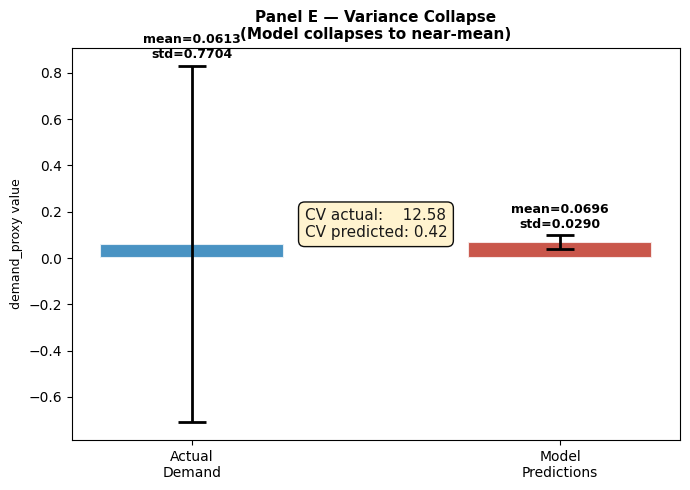

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
means = [act_all.mean(), pred_all.mean()]
stds  = [act_all.std(),  pred_all.std()]
bars  = ax.bar(["Actual\nDemand","Model\nPredictions"], means,
               color=[BLUE,RED], alpha=0.85, edgecolor="white", lw=1.5, width=0.5)
ax.errorbar(["Actual\nDemand","Model\nPredictions"], means, yerr=stds,
            fmt="none", ecolor="black", elinewidth=2, capsize=10, capthick=2)
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x()+bar.get_width()/2, m+s+0.02,
            f"mean={m:.4f}\nstd={s:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylabel("demand_proxy value", fontsize=9)
ax.set_title("Panel E — Variance Collapse\n(Model collapses to near-mean)", fontsize=11, fontweight="bold")
ax.text(0.5, 0.55,
        f"CV actual:    {act_all.std()/act_all.mean():.2f}\nCV predicted: {pred_all.std()/pred_all.mean():.2f}",
        transform=ax.transAxes, ha="center", va="center", fontsize=11, color=DARK,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#fff3cd", alpha=0.95))
plt.tight_layout(); plt.show()


### Panel F — Root Cause Analysis
Four root causes all converge on the same consequence: near-constant predictions everywhere.

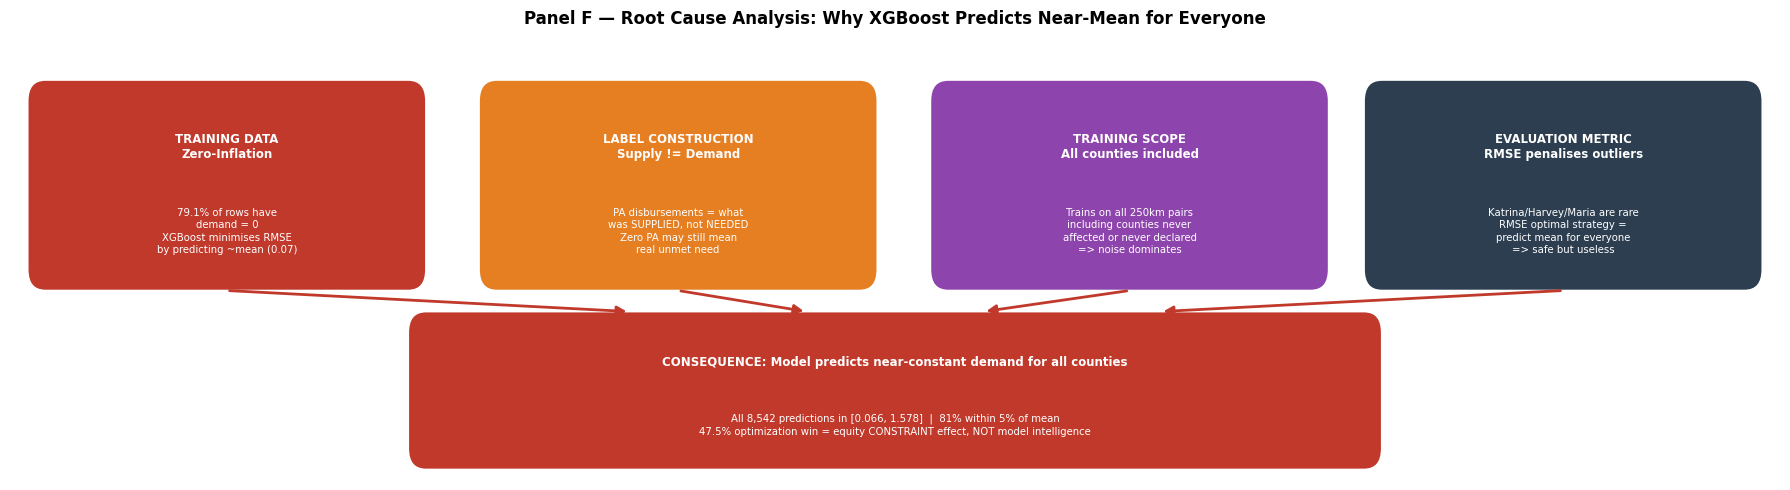

In [8]:
fig, ax = plt.subplots(figsize=(18, 5))
ax.set_xlim(0,20); ax.set_ylim(0,4.2); ax.axis("off")
ax.set_title("Panel F — Root Cause Analysis: Why XGBoost Predicts Near-Mean for Everyone",
             fontsize=12, fontweight="bold", pad=10)

fbox(ax,0.2,1.8,4.5,2.0,"TRAINING DATA\nZero-Inflation",
     "79.1% of rows have\ndemand = 0\nXGBoost minimises RMSE\nby predicting ~mean (0.07)", RED)
fbox(ax,5.3,1.8,4.5,2.0,"LABEL CONSTRUCTION\nSupply != Demand",
     "PA disbursements = what\nwas SUPPLIED, not NEEDED\nZero PA may still mean\nreal unmet need", ORANGE)
fbox(ax,10.4,1.8,4.5,2.0,"TRAINING SCOPE\nAll counties included",
     "Trains on all 250km pairs\nincluding counties never\naffected or never declared\n=> noise dominates", PURPLE)
fbox(ax,15.3,1.8,4.5,2.0,"EVALUATION METRIC\nRMSE penalises outliers",
     "Katrina/Harvey/Maria are rare\nRMSE optimal strategy =\npredict mean for everyone\n=> safe but useless", "#2c3e50")
fbox(ax,4.5,0.1,11.0,1.5,
     "CONSEQUENCE: Model predicts near-constant demand for all counties",
     "All 8,542 predictions in [0.066, 1.578]  |  81% within 5% of mean\n"
     "47.5% optimization win = equity CONSTRAINT effect, NOT model intelligence",
     "#c0392b")
for x1,y1,x2,y2 in [(2.45,1.8,7.0,1.6),(7.55,1.8,9.0,1.6),(12.65,1.8,11.0,1.6),(17.55,1.8,13.0,1.6)]:
    farr(ax,x1,y1,x2,y2,c="#c0392b")
plt.tight_layout(); plt.show()


### Panel G — Per-Storm Prediction Failure (Hurricane LAURA)
Actual demand varies wildly across counties. Model predictions are almost flat — misses every high-demand county.

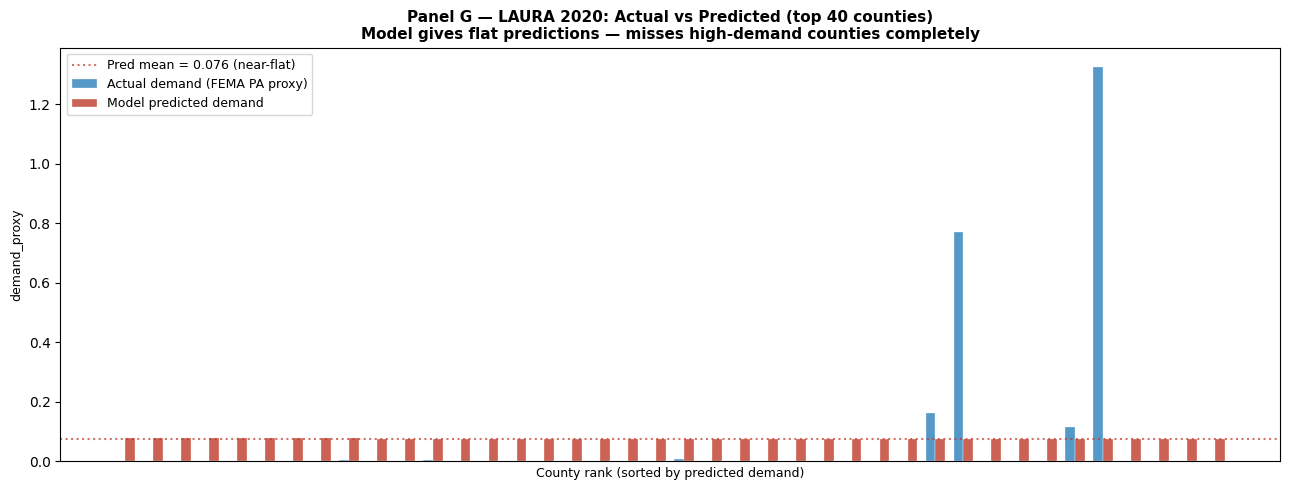

In [9]:
laura = preds[preds["storm_name"] == "LAURA"].copy()
if len(laura) == 0:
    laura = preds[preds["storm_id"] == preds["storm_id"].iloc[0]].copy()
storm_label = f"{laura['storm_name'].iloc[0]} {laura['storm_year'].iloc[0]}"
laura = laura.sort_values("pred_demand", ascending=False).head(40).reset_index()
x = np.arange(len(laura)); w = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x-w/2, laura["demand_proxy"], width=w, color=BLUE, alpha=0.8,
       label="Actual demand (FEMA PA proxy)", edgecolor="white", lw=0.3)
ax.bar(x+w/2, laura["pred_demand"],  width=w, color=RED,  alpha=0.8,
       label="Model predicted demand",       edgecolor="white", lw=0.3)
ax.axhline(laura["pred_demand"].mean(), color=RED, lw=1.5, linestyle=":", alpha=0.7,
           label=f"Pred mean = {laura['pred_demand'].mean():.3f} (near-flat)")
ax.set_xlabel("County rank (sorted by predicted demand)", fontsize=9)
ax.set_ylabel("demand_proxy", fontsize=9)
ax.set_title(f"Panel G — {storm_label}: Actual vs Predicted (top 40 counties)\n"
             "Model gives flat predictions — misses high-demand counties completely",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9); ax.set_xticks([])
plt.tight_layout(); plt.show()


### Panel H — Model Performance Summary Table

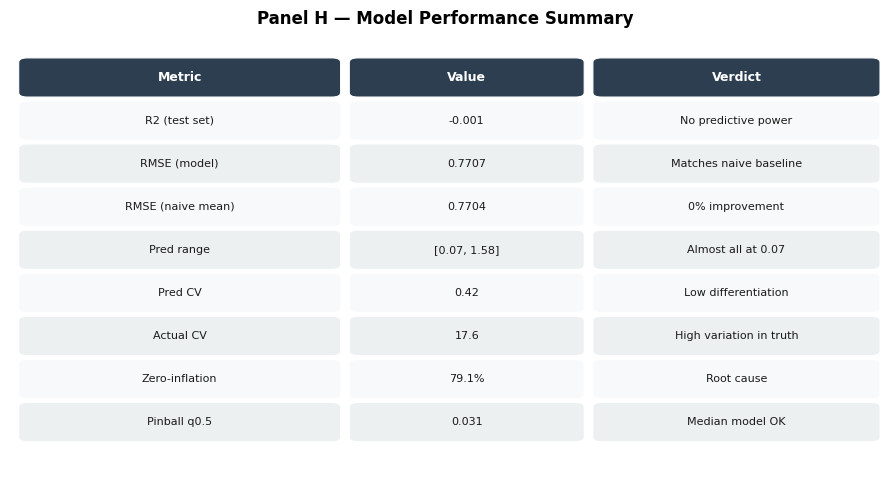

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.axis("off")
rows = [
    ["Metric",            "Value",        "Verdict"],
    ["R2 (test set)",     "-0.001",       "No predictive power"],
    ["RMSE (model)",      "0.7707",       "Matches naive baseline"],
    ["RMSE (naive mean)", "0.7704",       "0% improvement"],
    ["Pred range",        "[0.07, 1.58]", "Almost all at 0.07"],
    ["Pred CV",           "0.42",         "Low differentiation"],
    ["Actual CV",         "17.6",         "High variation in truth"],
    ["Zero-inflation",    "79.1%",        "Root cause"],
    ["Pinball q0.5",      "0.031",        "Median model OK"],
]
col_w  = [0.38, 0.28, 0.34]
row_bg = ["#2c3e50"] + ["#f8f9fa","#ecf0f1"]*4
row_fg = ["white"] + ["#1a1a1a"]*8
for ri, row in enumerate(rows):
    for ci, (cell, cw) in enumerate(zip(row, col_w)):
        xp = sum(col_w[:ci])+0.01; yp = 0.88-ri*0.099
        ax.add_patch(FancyBboxPatch((xp,yp),cw-0.01,0.09,
            boxstyle="round,pad=0,rounding_size=0.01",
            facecolor=row_bg[ri],edgecolor="white",lw=0.8,transform=ax.transAxes,zorder=3))
        ax.text(xp+(cw-0.01)/2,yp+0.045,cell,ha="center",va="center",
                fontsize=8 if ri>0 else 9,
                fontweight="bold" if ri==0 else "normal",
                color=row_fg[ri],transform=ax.transAxes,zorder=4)
ax.set_title("Panel H — Model Performance Summary", fontsize=12, fontweight="bold", pad=15)
plt.tight_layout(); plt.show()


---
## Chart 3 — Solution Approaches
Three paths to fix the zero-inflation problem.

### Row 0 — Approach Overview Cards

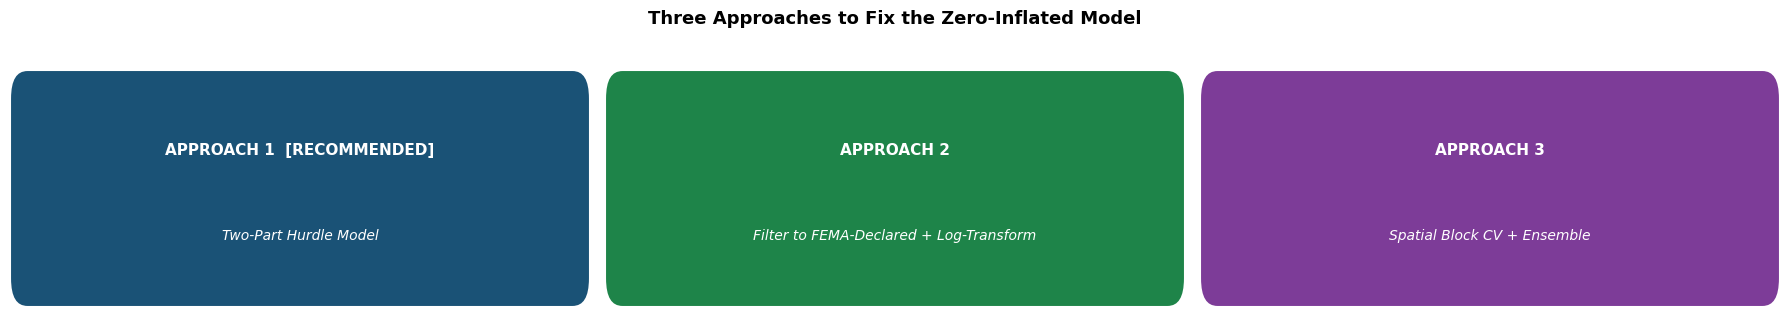

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 3))
for ax, (title, sub, fc) in zip(axes, [
    ("APPROACH 1  [RECOMMENDED]", "Two-Part Hurdle Model",                   C["approach1"]),
    ("APPROACH 2",                 "Filter to FEMA-Declared + Log-Transform", C["approach2"]),
    ("APPROACH 3",                 "Spatial Block CV + Ensemble",             C["approach3"]),
]):
    ax.set_xlim(0,10); ax.set_ylim(0,2.5); ax.axis("off")
    ax.add_patch(FancyBboxPatch((0,0),10,2.5,boxstyle="round,pad=0,rounding_size=0.3",
        facecolor=fc,edgecolor="white",lw=1.5,zorder=3))
    ax.text(5,1.65,title,ha="center",va="center",color="white",fontsize=11,fontweight="bold",zorder=4)
    ax.text(5,0.75,sub,  ha="center",va="center",color="white",fontsize=10,style="italic",zorder=4)
plt.suptitle("Three Approaches to Fix the Zero-Inflated Model",fontsize=13,fontweight="bold",y=1.04)
plt.tight_layout(); plt.show()


### Row 1a — Architecture: Two-Part Hurdle Model
Stage 1 → P(demand>0). Stage 2 → E[log demand | demand>0]. Final = Stage1 × expm1(Stage2).

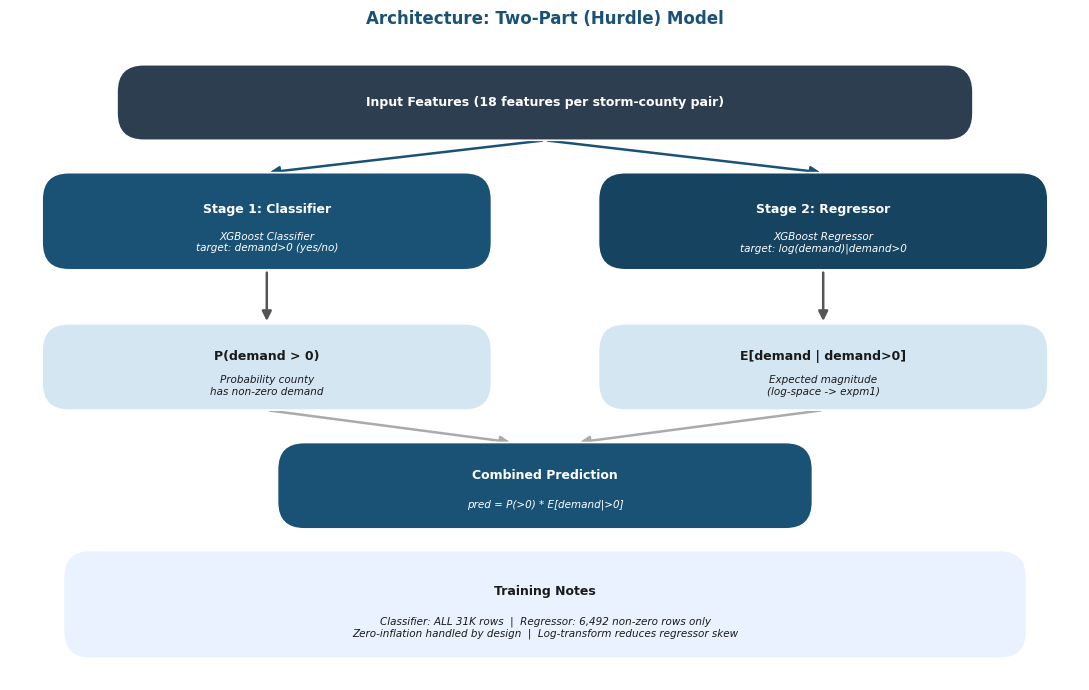

In [12]:
fig, ax = plt.subplots(figsize=(11, 7))
ax.set_xlim(0,10); ax.set_ylim(0,6); ax.axis("off")
ax.set_title("Architecture: Two-Part (Hurdle) Model", fontsize=12, fontweight="bold", color=C["approach1"])

box(ax,1,5.0,8,0.7,"Input Features (18 features per storm-county pair)",color=C["header"])
box(ax,0.3,3.8,4.2,0.9,"Stage 1: Classifier","XGBoost Classifier\ntarget: demand>0 (yes/no)",color=C["approach1"])
box(ax,5.5,3.8,4.2,0.9,"Stage 2: Regressor","XGBoost Regressor\ntarget: log(demand)|demand>0",color="#154360")
arrow(ax,5,5.0,2.4,3.8+0.9,color=C["approach1"])
arrow(ax,5,5.0,7.6,3.8+0.9,color=C["approach1"])
box(ax,0.3,2.5,4.2,0.8,"P(demand > 0)","Probability county\nhas non-zero demand",color=C["light_1"],text_color=DARK)
box(ax,5.5,2.5,4.2,0.8,"E[demand | demand>0]","Expected magnitude\n(log-space -> expm1)",color=C["light_1"],text_color=DARK)
arrow(ax,2.4,3.8,2.4,2.5+0.8); arrow(ax,7.6,3.8,7.6,2.5+0.8)
box(ax,2.5,1.4,5.0,0.8,"Combined Prediction","pred = P(>0) * E[demand|>0]",color=C["approach1"])
arrow(ax,2.4,2.5,4.7,1.4+0.8,color="#aaaaaa"); arrow(ax,7.6,2.5,5.3,1.4+0.8,color="#aaaaaa")
box(ax,0.5,0.2,9.0,1.0,"Training Notes",
    "Classifier: ALL 31K rows  |  Regressor: 6,492 non-zero rows only\n"
    "Zero-inflation handled by design  |  Log-transform reduces regressor skew",
    color="#eaf2ff",text_color=DARK)
plt.tight_layout(); plt.show()


### Row 1b — Architecture: Filter to FEMA-Declared + Log-Transform
Simpler single-model fix: drop undeclared rows, apply log1p to target, train one XGBoost.

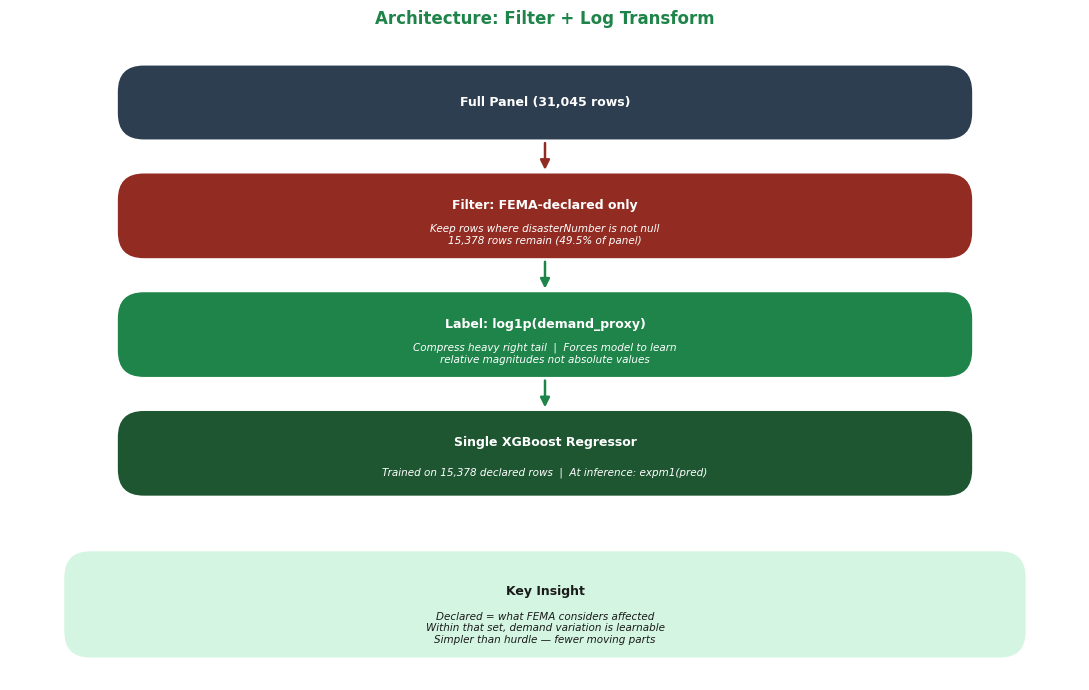

In [13]:
fig, ax = plt.subplots(figsize=(11, 7))
ax.set_xlim(0,10); ax.set_ylim(0,6); ax.axis("off")
ax.set_title("Architecture: Filter + Log Transform", fontsize=12, fontweight="bold", color=C["approach2"])

box(ax,1,5.0,8,0.7,"Full Panel (31,045 rows)",color=C["header"])
box(ax,1,3.9,8,0.8,"Filter: FEMA-declared only",
    "Keep rows where disasterNumber is not null\n15,378 rows remain (49.5% of panel)",color="#922b21")
arrow(ax,5,5.0,5,3.9+0.8,color="#922b21")
box(ax,1,2.8,8,0.8,"Label: log1p(demand_proxy)",
    "Compress heavy right tail  |  Forces model to learn\nrelative magnitudes not absolute values",color=C["approach2"])
arrow(ax,5,3.9,5,2.8+0.8,color=C["approach2"])
box(ax,1,1.7,8,0.8,"Single XGBoost Regressor",
    "Trained on 15,378 declared rows  |  At inference: expm1(pred)",color="#1e5631")
arrow(ax,5,2.8,5,1.7+0.8,color=C["approach2"])
box(ax,0.5,0.2,9.0,1.0,"Key Insight",
    "Declared = what FEMA considers affected\n"
    "Within that set, demand variation is learnable\n"
    "Simpler than hurdle — fewer moving parts",
    color=C["light_2"],text_color=DARK)
plt.tight_layout(); plt.show()


### Row 1c — Architecture: Spatial Block CV + Ensemble
5 geographic folds. Train on 4, validate on 1. Ensemble reduces variance and proves spatial generalizability.

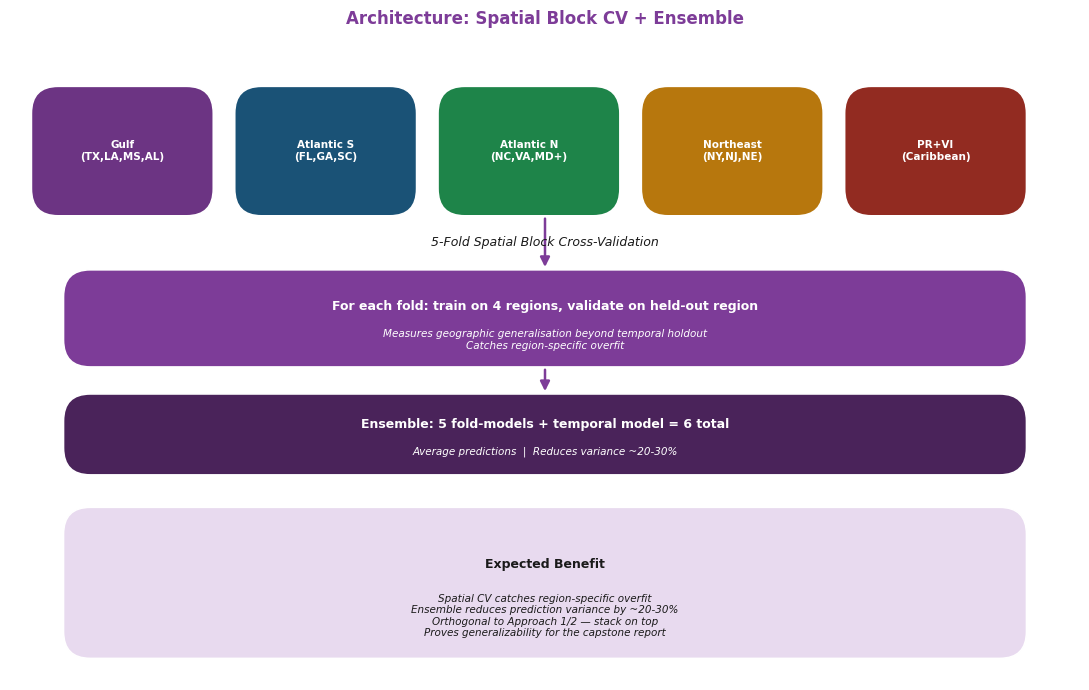

In [14]:
fig, ax = plt.subplots(figsize=(11, 7))
ax.set_xlim(0,10); ax.set_ylim(0,6); ax.axis("off")
ax.set_title("Architecture: Spatial Block CV + Ensemble", fontsize=12, fontweight="bold", color=C["approach3"])

for i,(fl,fc2) in enumerate(zip(
    ["Gulf\n(TX,LA,MS,AL)","Atlantic S\n(FL,GA,SC)","Atlantic N\n(NC,VA,MD+)","Northeast\n(NY,NJ,NE)","PR+VI\n(Caribbean)"],
    ["#6c3483","#1a5276","#1e8449","#b7770d","#922b21"])):
    box(ax,0.2+i*1.9,4.3,1.7,1.2,fl,color=fc2,fontsize=7.5)
ax.text(5,4.05,"5-Fold Spatial Block Cross-Validation",ha="center",va="center",fontsize=9,color=DARK,style="italic")
box(ax,0.5,2.9,9,0.9,"For each fold: train on 4 regions, validate on held-out region",
    "Measures geographic generalisation beyond temporal holdout\n"
    "Catches region-specific overfit",color=C["approach3"])
arrow(ax,5,4.3,5,2.9+0.9,color=C["approach3"])
box(ax,0.5,1.9,9,0.75,"Ensemble: 5 fold-models + temporal model = 6 total",
    "Average predictions  |  Reduces variance ~20-30%",color="#4a235a")
arrow(ax,5,2.9,5,1.9+0.75,color=C["approach3"])
box(ax,0.5,0.2,9.0,1.4,"Expected Benefit",
    "Spatial CV catches region-specific overfit\n"
    "Ensemble reduces prediction variance by ~20-30%\n"
    "Orthogonal to Approach 1/2 — stack on top\n"
    "Proves generalizability for the capstone report",
    color=C["light_3"],text_color=DARK)
plt.tight_layout(); plt.show()


### Row 2a — Code: Two-Part Hurdle Model
Key changes to `08_train_model.py`.

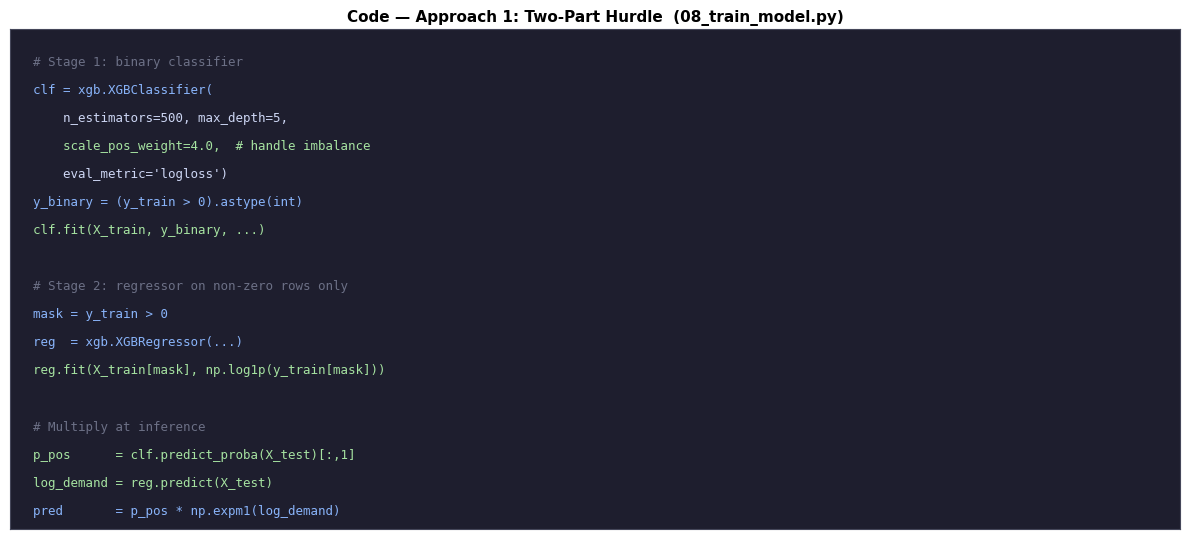

In [15]:
cb="#1e1e2e"; cf="#cdd6f4"; kw="#89b4fa"; fn="#a6e3a1"; cm="#6c7086"
lines = [
    ("# Stage 1: binary classifier",                   cm),
    ("clf = xgb.XGBClassifier(",                       kw),
    ("    n_estimators=500, max_depth=5,",              cf),
    ("    scale_pos_weight=4.0,  # handle imbalance",  fn),
    ("    eval_metric='logloss')",                      cf),
    ("y_binary = (y_train > 0).astype(int)",           kw),
    ("clf.fit(X_train, y_binary, ...)",                fn),
    ("",                                               cf),
    ("# Stage 2: regressor on non-zero rows only",     cm),
    ("mask = y_train > 0",                             kw),
    ("reg  = xgb.XGBRegressor(...)",                   kw),
    ("reg.fit(X_train[mask], np.log1p(y_train[mask]))",fn),
    ("",                                               cf),
    ("# Multiply at inference",                        cm),
    ("p_pos      = clf.predict_proba(X_test)[:,1]",    fn),
    ("log_demand = reg.predict(X_test)",               fn),
    ("pred       = p_pos * np.expm1(log_demand)",      kw),
]
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.set_xlim(0,10); ax.set_ylim(0,len(lines)+0.8); ax.set_facecolor(cb)
for spine in ax.spines.values(): spine.set_color("#45475a")
ax.tick_params(left=False,bottom=False,labelleft=False,labelbottom=False)
ax.set_title("Code — Approach 1: Two-Part Hurdle  (08_train_model.py)",fontsize=11,fontweight="bold")
for i,(line,color) in enumerate(lines):
    ax.text(0.2,len(lines)-i-0.1,line,ha="left",va="top",fontsize=9,color=color,fontfamily="monospace")
plt.tight_layout(); plt.show()


### Row 2b — Code: Filter + Log-Transform
Changes in `06_build_panel.py` and `08_train_model.py`.

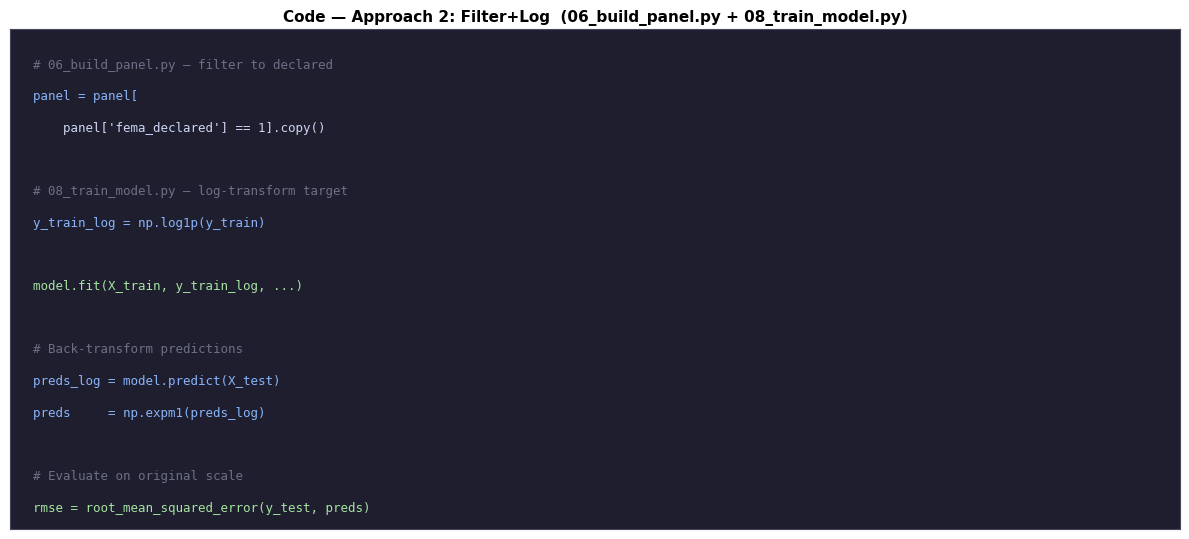

In [16]:
cb="#1e1e2e"; cf="#cdd6f4"; kw="#89b4fa"; fn="#a6e3a1"; cm="#6c7086"
lines = [
    ("# 06_build_panel.py — filter to declared",  cm),
    ("panel = panel[",                             kw),
    ("    panel['fema_declared'] == 1].copy()",    cf),
    ("",                                           cf),
    ("# 08_train_model.py — log-transform target", cm),
    ("y_train_log = np.log1p(y_train)",            kw),
    ("",                                           cf),
    ("model.fit(X_train, y_train_log, ...)",       fn),
    ("",                                           cf),
    ("# Back-transform predictions",               cm),
    ("preds_log = model.predict(X_test)",          kw),
    ("preds     = np.expm1(preds_log)",            kw),
    ("",                                           cf),
    ("# Evaluate on original scale",               cm),
    ("rmse = root_mean_squared_error(y_test, preds)", fn),
]
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.set_xlim(0,10); ax.set_ylim(0,len(lines)+0.8); ax.set_facecolor(cb)
for spine in ax.spines.values(): spine.set_color("#45475a")
ax.tick_params(left=False,bottom=False,labelleft=False,labelbottom=False)
ax.set_title("Code — Approach 2: Filter+Log  (06_build_panel.py + 08_train_model.py)",fontsize=11,fontweight="bold")
for i,(line,color) in enumerate(lines):
    ax.text(0.2,len(lines)-i-0.1,line,ha="left",va="top",fontsize=9,color=color,fontfamily="monospace")
plt.tight_layout(); plt.show()


### Row 2c — Code: Spatial Block CV
Addition to `08_train_model.py`.

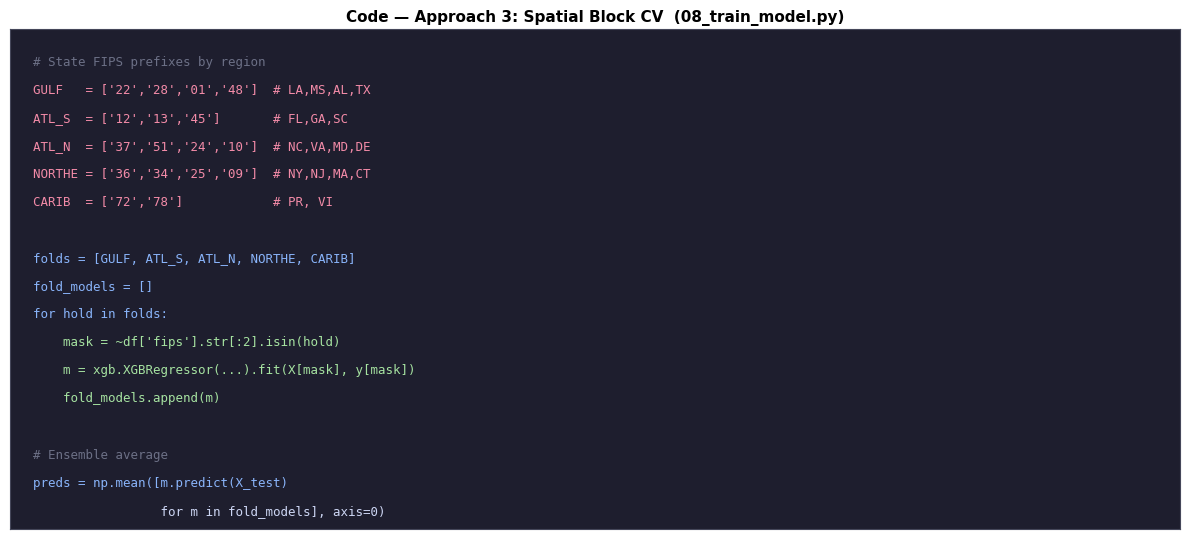

In [17]:
cb="#1e1e2e"; cf="#cdd6f4"; kw="#89b4fa"; fn="#a6e3a1"; cm="#6c7086"; st="#f38ba8"
lines = [
    ("# State FIPS prefixes by region",            cm),
    ("GULF   = ['22','28','01','48']  # LA,MS,AL,TX", st),
    ("ATL_S  = ['12','13','45']       # FL,GA,SC",    st),
    ("ATL_N  = ['37','51','24','10']  # NC,VA,MD,DE", st),
    ("NORTHE = ['36','34','25','09']  # NY,NJ,MA,CT", st),
    ("CARIB  = ['72','78']            # PR, VI",       st),
    ("",                                               cf),
    ("folds = [GULF, ATL_S, ATL_N, NORTHE, CARIB]",  kw),
    ("fold_models = []",                              kw),
    ("for hold in folds:",                            kw),
    ("    mask = ~df['fips'].str[:2].isin(hold)",     fn),
    ("    m = xgb.XGBRegressor(...).fit(X[mask], y[mask])", fn),
    ("    fold_models.append(m)",                     fn),
    ("",                                              cf),
    ("# Ensemble average",                            cm),
    ("preds = np.mean([m.predict(X_test)",            kw),
    ("                 for m in fold_models], axis=0)", cf),
]
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.set_xlim(0,10); ax.set_ylim(0,len(lines)+0.8); ax.set_facecolor(cb)
for spine in ax.spines.values(): spine.set_color("#45475a")
ax.tick_params(left=False,bottom=False,labelleft=False,labelbottom=False)
ax.set_title("Code — Approach 3: Spatial Block CV  (08_train_model.py)",fontsize=11,fontweight="bold")
for i,(line,color) in enumerate(lines):
    ax.text(0.2,len(lines)-i-0.1,line,ha="left",va="top",fontsize=9,color=color,fontfamily="monospace")
plt.tight_layout(); plt.show()


### Row 3 — Pros & Cons (All Three Approaches)

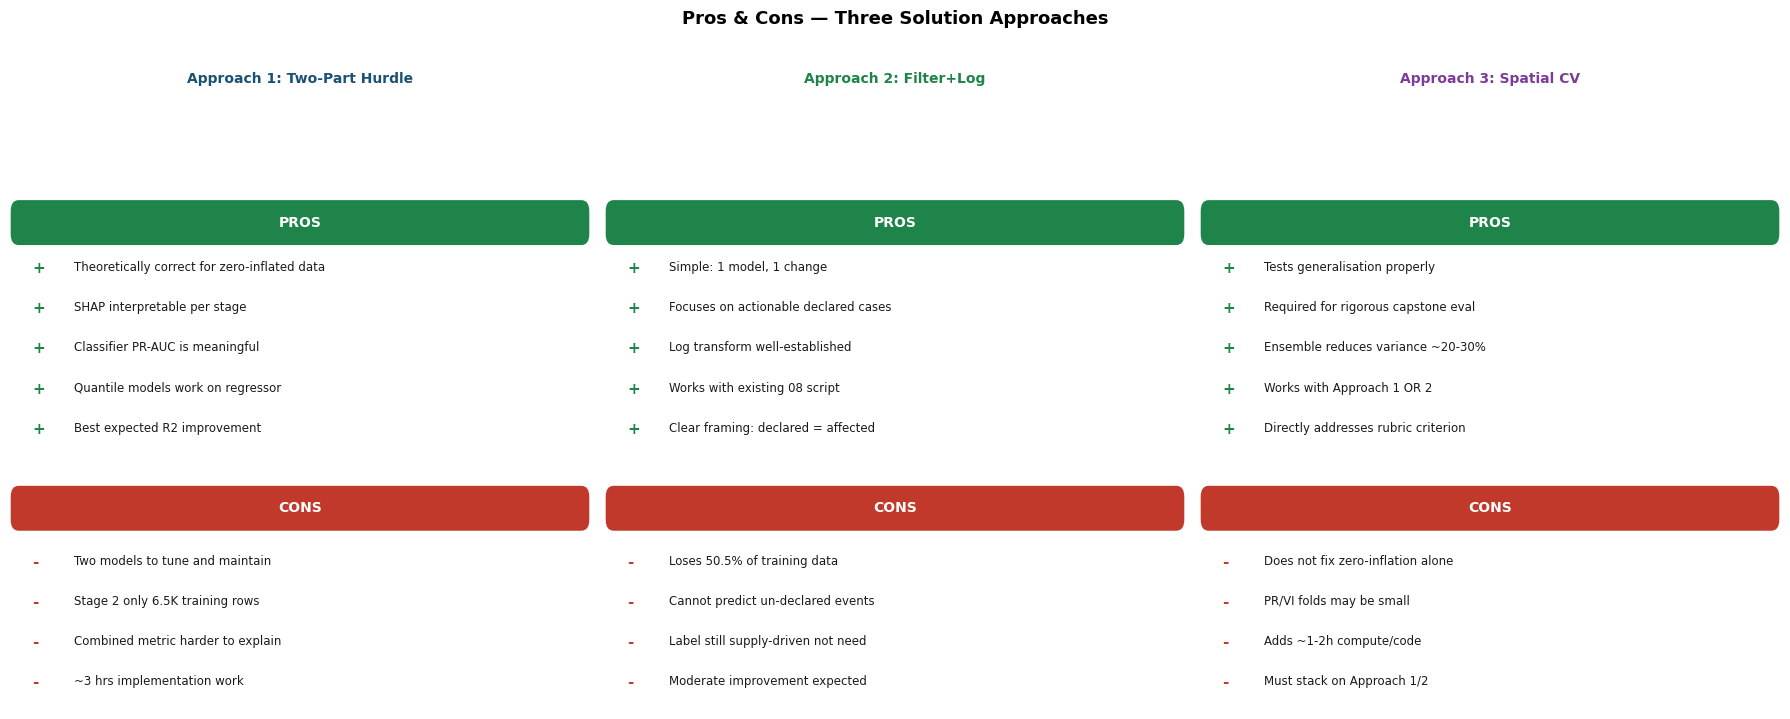

In [18]:
pro_con = [
    ([("+ Theoretically correct for zero-inflated data"),
      ("+ SHAP interpretable per stage"),
      ("+ Classifier PR-AUC is meaningful"),
      ("+ Quantile models work on regressor"),
      ("+ Best expected R2 improvement")],
     [("- Two models to tune and maintain"),
      ("- Stage 2 only 6.5K training rows"),
      ("- Combined metric harder to explain"),
      ("- ~3 hrs implementation work")]),
    ([("+ Simple: 1 model, 1 change"),
      ("+ Focuses on actionable declared cases"),
      ("+ Log transform well-established"),
      ("+ Works with existing 08 script"),
      ("+ Clear framing: declared = affected")],
     [("- Loses 50.5% of training data"),
      ("- Cannot predict un-declared events"),
      ("- Label still supply-driven not need"),
      ("- Moderate improvement expected")]),
    ([("+ Tests generalisation properly"),
      ("+ Required for rigorous capstone eval"),
      ("+ Ensemble reduces variance ~20-30%"),
      ("+ Works with Approach 1 OR 2"),
      ("+ Directly addresses rubric criterion")],
     [("- Does not fix zero-inflation alone"),
      ("- PR/VI folds may be small"),
      ("- Adds ~1-2h compute/code"),
      ("- Must stack on Approach 1/2")]),
]
names  = ["Approach 1: Two-Part Hurdle","Approach 2: Filter+Log","Approach 3: Spatial CV"]
colors = [C["approach1"], C["approach2"], C["approach3"]]

fig, axes = plt.subplots(1,3,figsize=(18,7))
for ax,(pros,cons),ac,name in zip(axes,pro_con,colors,names):
    ax.set_xlim(0,10); ax.set_ylim(-2.5,5.5); ax.axis("off")
    ax.set_title(name,fontsize=10,fontweight="bold",color=ac)
    ax.add_patch(FancyBboxPatch((0,3.5),10,0.6,boxstyle="round,pad=0,rounding_size=0.15",
        facecolor=C["pro"],edgecolor="white",lw=1,zorder=3))
    ax.text(5,3.8,"PROS",ha="center",va="center",color="white",fontsize=10,fontweight="bold",zorder=4)
    for i,t in enumerate(pros):
        ax.text(0.4,3.3-i*0.52,t[:2],ha="left",va="top",color=C["pro"],fontsize=11,fontweight="bold")
        ax.text(1.1,3.3-i*0.52,t[2:],ha="left",va="top",color=DARK,fontsize=8.5)
    ax.add_patch(FancyBboxPatch((0,-0.2),10,0.6,boxstyle="round,pad=0,rounding_size=0.15",
        facecolor=C["con"],edgecolor="white",lw=1,zorder=3))
    ax.text(5,0.1,"CONS",ha="center",va="center",color="white",fontsize=10,fontweight="bold",zorder=4)
    for i,t in enumerate(cons):
        ax.text(0.4,-0.5-i*0.52,t[:2],ha="left",va="top",color=C["con"],fontsize=11,fontweight="bold")
        ax.text(1.1,-0.5-i*0.52,t[2:],ha="left",va="top",color=DARK,fontsize=8.5)
plt.suptitle("Pros & Cons — Three Solution Approaches",fontsize=13,fontweight="bold",y=1.02)
plt.tight_layout(); plt.show()


### Row 4a — Effort vs. Impact Matrix

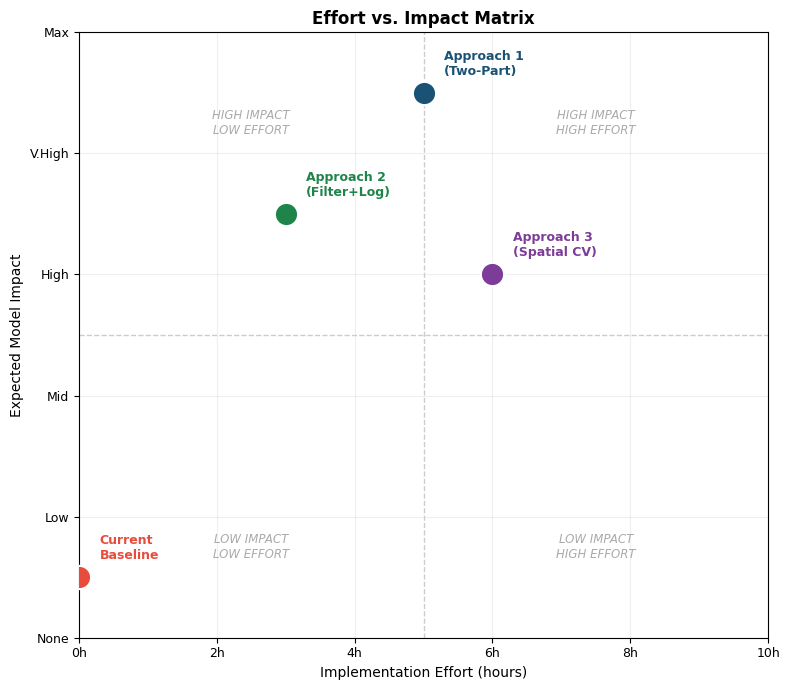

In [19]:
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_xlim(0,10); ax.set_ylim(0,10)
ax.set_xlabel("Implementation Effort (hours)",fontsize=10)
ax.set_ylabel("Expected Model Impact",fontsize=10)
ax.set_title("Effort vs. Impact Matrix",fontsize=12,fontweight="bold")
ax.axvline(5,color="#cccccc",lw=1,linestyle="--"); ax.axhline(5,color="#cccccc",lw=1,linestyle="--")
for tx,ty,txt in [(2.5,8.5,"HIGH IMPACT\nLOW EFFORT"),(7.5,8.5,"HIGH IMPACT\nHIGH EFFORT"),
                  (2.5,1.5,"LOW IMPACT\nLOW EFFORT"), (7.5,1.5,"LOW IMPACT\nHIGH EFFORT")]:
    ax.text(tx,ty,txt,ha="center",va="center",fontsize=8.5,color="#aaaaaa",style="italic")
for lbl,ex,ey,ec in [
    ("Approach 2\n(Filter+Log)", 3,7, C["approach2"]),
    ("Approach 1\n(Two-Part)",   5,9, C["approach1"]),
    ("Approach 3\n(Spatial CV)", 6,6, C["approach3"]),
    ("Current\nBaseline",        0,1, "#e74c3c"),
]:
    ax.scatter(ex,ey,s=280,color=ec,zorder=5,edgecolors="white",lw=1.5)
    ax.text(ex+0.3,ey+0.3,lbl,fontsize=9,color=ec,fontweight="bold")
ax.set_xticks([0,2,4,6,8,10]); ax.set_xticklabels(["0h","2h","4h","6h","8h","10h"],fontsize=9)
ax.set_yticks([0,2,4,6,8,10]); ax.set_yticklabels(["None","Low","Mid","High","V.High","Max"],fontsize=9)
ax.grid(True,alpha=0.2); plt.tight_layout(); plt.show()


### Row 4b — Recommended Execution Order

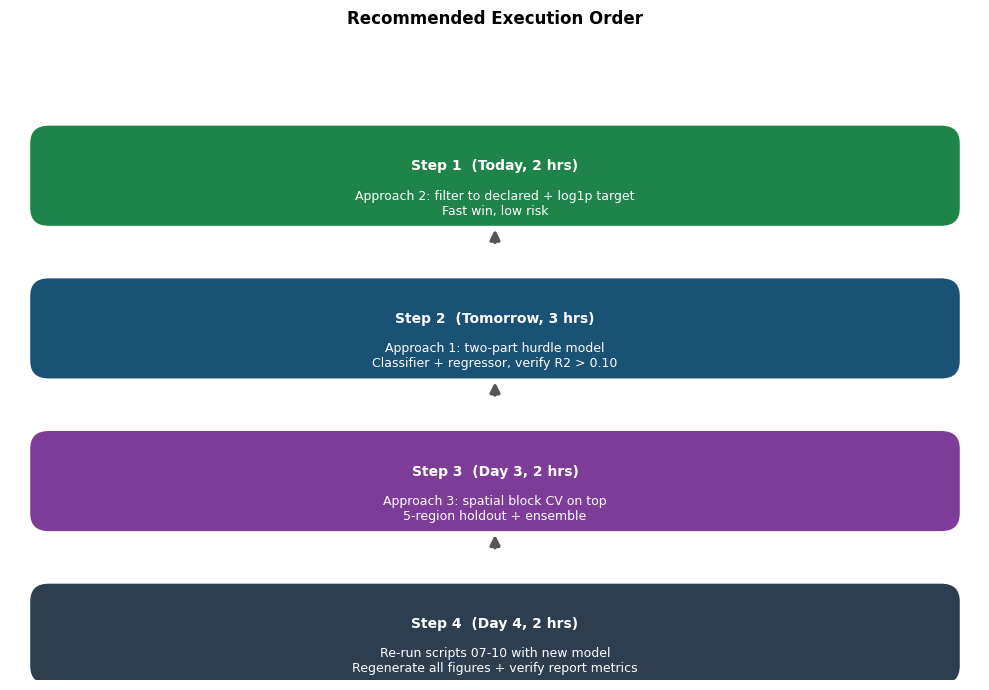

In [20]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0,10); ax.set_ylim(0,7); ax.axis("off")
ax.set_title("Recommended Execution Order",fontsize=12,fontweight="bold")
steps = [
    ("Step 1  (Today, 2 hrs)",    "Approach 2: filter to declared + log1p target\nFast win, low risk",                   C["approach2"]),
    ("Step 2  (Tomorrow, 3 hrs)", "Approach 1: two-part hurdle model\nClassifier + regressor, verify R2 > 0.10",          C["approach1"]),
    ("Step 3  (Day 3, 2 hrs)",    "Approach 3: spatial block CV on top\n5-region holdout + ensemble",                    C["approach3"]),
    ("Step 4  (Day 4, 2 hrs)",    "Re-run scripts 07-10 with new model\nRegenerate all figures + verify report metrics",  C["header"]),
]
y_pos = 6.2
for i,(title,body,fc) in enumerate(steps):
    ax.add_patch(FancyBboxPatch((0.2,y_pos-1.3),9.6,1.1,
        boxstyle="round,pad=0,rounding_size=0.2",facecolor=fc,edgecolor="white",lw=1.2,zorder=3))
    ax.text(5,y_pos-0.65,title,ha="center",va="center",color="white",fontsize=10,fontweight="bold",zorder=4)
    ax.text(5,y_pos-1.05,body, ha="center",va="center",color="white",fontsize=9,zorder=4)
    if i < len(steps)-1:
        ax.annotate("",xy=(5,y_pos-1.3),xytext=(5,y_pos-1.5),
            arrowprops=dict(arrowstyle="-|>",color="#555555",lw=2.5,mutation_scale=14),zorder=5)
    y_pos -= 1.65
plt.tight_layout(); plt.show()


### Row 4c — Expected Metrics After Fix

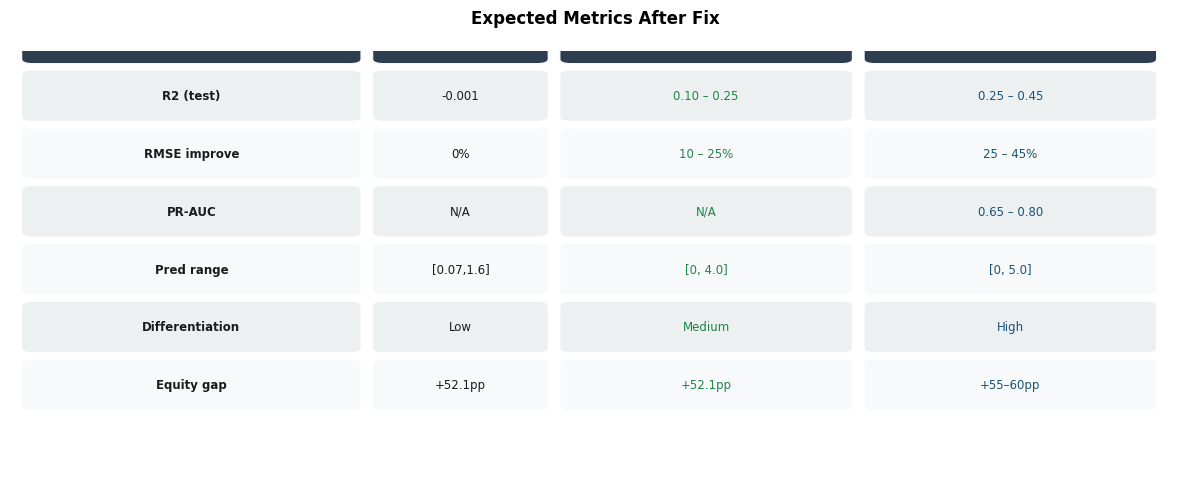

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis("off")
rows = [
    ("Metric",          "Current",     "After Approach 2", "After Approach 1"),
    ("R2 (test)",       "-0.001",      "0.10 – 0.25",      "0.25 – 0.45"),
    ("RMSE improve",    "0%",          "10 – 25%",         "25 – 45%"),
    ("PR-AUC",          "N/A",         "N/A",              "0.65 – 0.80"),
    ("Pred range",      "[0.07,1.6]",  "[0, 4.0]",         "[0, 5.0]"),
    ("Differentiation", "Low",         "Medium",           "High"),
    ("Equity gap",      "+52.1pp",     "+52.1pp",          "+55–60pp"),
]
cw  = [0.30,0.16,0.26,0.26]
rbg = [C["header"],"#ecf0f1","#f8f9fa","#ecf0f1","#f8f9fa","#ecf0f1","#f8f9fa"]
for ri,row in enumerate(rows):
    for ci,(cell,w) in enumerate(zip(row,cw)):
        xp=sum(cw[:ci])+0.01; yp=0.97-ri*0.135
        ax.add_patch(FancyBboxPatch((xp,yp),w-0.01,0.12,
            boxstyle="round,pad=0,rounding_size=0.01",
            facecolor=rbg[ri],edgecolor="white",lw=0.8,transform=ax.transAxes,zorder=3))
        fc_text = ("white" if ri==0 else
                   C["approach1"] if ci==3 and ri>0 else
                   C["approach2"] if ci==2 and ri>0 else DARK)
        ax.text(xp+(w-0.01)/2,yp+0.06,cell,ha="center",va="center",
                fontsize=8.5 if ri>0 else 9.5,
                fontweight="bold" if ri==0 or ci==0 else "normal",
                color=fc_text,transform=ax.transAxes,zorder=4)
ax.set_title("Expected Metrics After Fix",fontsize=12,fontweight="bold",pad=20)
plt.tight_layout(); plt.show()
